# Challenges in Representation Learning: Facial Expression Recognition Challenge

https://www.kaggle.com/c/challenges-in-representation-learning-facial-expression-recognition-challenge

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import keras
from keras.preprocessing import image

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.mixed_precision import experimental as mixed_precision

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("API de precisão mista experimental encontrada. Habilitando...")
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_policy(policy)
    
    print("Política de precisão experimental definida com sucesso.")
else:
    print("Nenhuma GPU encontrada. A precisão mista não será habilitada.")

API de precisão mista experimental encontrada. Habilitando...
Política de precisão experimental definida com sucesso.


In [4]:
from keras import applications as keras_applications

In [5]:
!pip install keras_applications
!pip install git+https://github.com/rcmalli/keras-vggface.git

     |████████████████████████████████| 50 kB 3.0 MB/s eta 0:00:011
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.
  Cloning https://github.com/rcmalli/keras-vggface.git to /tmp/pip-req-build-8bi6x2cr
  Created wheel for keras-vggface: filename=keras_vggface-0.6-py3-none-any.whl size=8301 sha256=e2c0b2148e05b5033278152e50642749a96ed9a015c3dadc603973cf2b98d71f
  Stored in directory: /tmp/pip-ephem-wheel-cache-vh8z7w9k/wheels/08/df/86/0225d44647ab2256dbf1e006823288fe9cc86367a056e6ea2c
Successfully built keras-vggface
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [6]:
from keras_vggface.vggface import VGGFace
from keras_vggface import utils

# Data Preprocess

In [ ]:
import pandas as pd
import numpy as np

print("--- Iniciando Carregamento dos Dados ---")

path_fer2013_orig = '/kaggle/input/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv'
path_fer2013_plus = '/kaggle/input/ferplus/fer2013new.csv'

try:
    data_orig = pd.read_csv(path_fer2013_orig)
    data_plus = pd.read_csv(path_fer2013_plus)
    print("Arquivos CSV carregados com sucesso.")
except FileNotFoundError as e:
    print(f"ERRO FATAL: Arquivo não encontrado. Verifique os caminhos.")
    print(e)
    raise

data_orig.columns = data_orig.columns.str.strip()

print(f"Colunas em icml_face_data.csv (original): {list(data_orig.columns)}")
print(f"Colunas em fer2013new.csv (plus): {list(data_plus.columns)}")

if 'pixels' not in data_orig.columns:
    print("ERRO FATAL: A coluna 'pixels' NÃO foi encontrada em icml_face_data.csv.")
    print("Por favor, verifique o arquivo.")
    raise AttributeError("Coluna 'pixels' não encontrada no CSV original.")
else:
    print("Coluna 'pixels' encontrada com sucesso.")
    
if 'Usage' not in data_plus.columns:
    print("ERRO FATAL: A coluna 'Usage' NÃO foi encontrada em fer2013new.csv.")
    raise AttributeError("Coluna 'Usage' não encontrada no CSV do FER-Plus.")
else:
    print("Coluna 'Usage' encontrada com sucesso no FER-Plus.")


data = pd.concat([data_orig['pixels'], data_plus], axis=1)
print("DataFrames concatenados.")

emotion_cols = ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']
other_cols = ['unknown', 'NF']

all_labels = emotion_cols + other_cols
data['majority_label_str'] = data[all_labels].idxmax(axis=1)

data = data[~data['majority_label_str'].isin(other_cols)]
print(f"Total de imagens após filtrar 'NF' e 'unknown': {len(data)}")

emotion_mapping = {label: idx for idx, label in enumerate(emotion_cols)}
data['emotion'] = data['majority_label_str'].map(emotion_mapping)
print("Rótulos do FER-Plus processados (voto majoritário).")

train_data = data[data.Usage=='Training']
val_data = data[data.Usage=='PublicTest']
test_data = data[data.Usage=='PrivateTest']
print("Dados divididos em Treino, Validação e Teste.")

print("\n--- DIAGNÓSTICO FINAL ---")
print(f"Colunas em 'train_data' (final): {list(train_data.columns)}")

if 'pixels' not in train_data.columns:
    print("ERRO: 'pixels' NÃO está em 'train_data' após a divisão.")
else:
    print("SUCESSO: 'pixels' está presente em 'train_data'.")
    
if 'emotion' not in train_data.columns:
    print("ERRO: 'emotion' NÃO está em 'train_data' após a divisão.")
else:
    print("SUCESSO: 'emotion' está presente em 'train_data'.")

print("--------------------------")

--- Iniciando Carregamento dos Dados ---
Arquivos CSV carregados com sucesso.
Colunas em icml_face_data.csv (original): ['emotion', 'Usage', 'pixels']
Colunas em fer2013new.csv (plus): ['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']
Coluna 'pixels' encontrada com sucesso.
Coluna 'Usage' encontrada com sucesso no FER-Plus.
DataFrames concatenados.
Total de imagens após filtrar 'NF' e 'unknown': 35488
Rótulos do FER-Plus processados (voto majoritário).
Dados divididos em Treino, Validação e Teste.

--- DIAGNÓSTICO FINAL ---
Colunas em 'train_data' (final): ['pixels', 'Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF', 'majority_label_str', 'emotion']
SUCESSO: 'pixels' está presente em 'train_data'.
SUCESSO: 'emotion' está presente em 'train_data'.
--------------------------


In [8]:
data.Usage.unique()

array(['Training', 'PublicTest', 'PrivateTest'], dtype=object)

In [9]:
train_data.shape, val_data.shape, test_data.shape

((28389, 15), (3553, 15), (3546, 15))

In [10]:
import collections
import imblearn
# oversampler = imblearn.over_sampling.RandomOverSampler()

In [11]:
collections.Counter(train_data.emotion)

Counter({0: 10309, 3: 3515, 1: 7528, 2: 3562, 4: 2467, 6: 652, 7: 165, 5: 191})

In [12]:
from keras.utils import to_categorical

# x_train, y_train = oversampler.fit_resample(train_data.pixels.values.reshape(-1,1),train_data.emotion.values)

# # x_train = train_data.pixels.values.reshape(-1,1)
# # y_train = train_data.emotion.values

# x_val = val_data.pixels.values.reshape(-1,1)
# y_val = val_data.emotion.values

# x_test = test_data.pixels.values.reshape(-1,1)
# y_test = test_data.emotion.values

In [ ]:
from sklearn.utils import class_weight
import numpy as np
import collections

print("--- Usando dados de treino originais (sem oversampling) ---")
x_train = train_data.pixels.values.reshape(-1, 1)
y_train = train_data.emotion.values

x_val = val_data.pixels.values.reshape(-1, 1)
y_val = val_data.emotion.values

x_test = test_data.pixels.values.reshape(-1, 1)
y_test = test_data.emotion.values

print("Distribuição original das classes de treino:", collections.Counter(y_train))


print("\n--- Calculando pesos de classe para balanceamento ---")
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train                  
)

class_weight_dict = {i: float(weight) for i, weight in enumerate(class_weights)}

print("Pesos de classe calculados (as classes minoritárias recebem um peso maior):")
print(class_weight_dict)

--- Usando dados de treino originais (sem oversampling) ---
Distribuição original das classes de treino: Counter({0: 10309, 1: 7528, 2: 3562, 3: 3515, 4: 2467, 6: 652, 5: 191, 7: 165})

--- Calculando pesos de classe para balanceamento ---
Pesos de classe calculados (as classes minoritárias recebem um peso maior):
{0: 0.3442259190998157, 1: 0.47139014346439956, 2: 0.9962450870297586, 3: 1.009566145092461, 4: 1.4384373733279288, 5: 18.57918848167539, 6: 5.442676380368098, 7: 21.506818181818183}


In [14]:
collections.Counter(y_train)

Counter({0: 10309, 3: 3515, 1: 7528, 2: 3562, 4: 2467, 6: 652, 7: 165, 5: 191})

In [15]:
x_train = list(x_train)
x_val   = list(x_val)
x_test  = list(x_test)

for i,item in enumerate(x_train):
    x_train[i] = np.fromstring(item[0], sep=' ').reshape(48,48,1).astype(np.uint8)
for i,item in enumerate(x_val):
    x_val[i] = np.fromstring(item[0], sep=' ').reshape(48,48,1).astype(np.uint8)
for i,item in enumerate(x_test):
    x_test[i] = np.fromstring(item[0], sep=' ').reshape(48,48,1).astype(np.uint8)
    
x_train = np.vstack(x_train).reshape(-1,48,48,1).astype(np.uint8)
x_val = np.vstack(x_val).reshape(-1,48,48,1).astype(np.uint8)
x_test = np.vstack(x_test).reshape(-1,48,48,1).astype(np.uint8)

In [16]:
y_train = to_categorical(y_train,num_classes=8)
y_val   = to_categorical(y_val  ,num_classes=8)
y_test  = to_categorical(y_test ,num_classes=8)

In [17]:
from copy import deepcopy as copy

def smooth_labels(y, smooth_factor):
    '''Convert a matrix of one-hot row-vector labels into smoothed versions.

    # Arguments
        y: matrix of one-hot row-vector labels to be smoothed
        smooth_factor: label smoothing factor (between 0 and 1)

    # Returns
        A matrix of smoothed labels.
    '''
    assert len(y.shape) == 2, 'input should be a batch of one-hot-encoded data'
    y2 = copy(y)
    if 0 <= smooth_factor <= 1:
        # label smoothing ref: https://www.robots.ox.ac.uk/~vgg/rg/papers/reinception.pdf
        y2 *= 1 - smooth_factor
        y2 += smooth_factor / y.shape[1]
    else:
        raise Exception(
            'Invalid label smoothing factor: ' + str(smooth_factor))
    return y2

In [18]:
!pip install albumentations
from keras.utils import Sequence
from keras.utils import to_categorical
import cv2
from math import floor
import albumentations as A

class data_sequence(Sequence):
    def __init__(self, features, labels, batch_size=128, target_dim=(224,224), 
                 n_classes=8, shuffle=True, augment=False):
        'Initialization'
        assert len(features)==len(labels), 'number of feature and labels not consistent'
        self.features = features
        self.labels = labels
        self.batch_size = batch_size
        self.target_dim = target_dim
        self.target_channels = 3
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.augment = augment
        self.sample_count = len(labels)
        self.indexes = np.arange(self.sample_count)

        if self.augment:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.Rotate(limit=15, p=0.7),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
                A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
            ])

    def __len__(self):
        'Denotes the number of batches per epoch'
        return floor(self.sample_count / self.batch_size)

    def __gray2RGB__(self,x):
      if len(x.shape)==2:
        return np.stack((x,x,x),-1)
      else:
        assert len(x.shape)==3
        if len(x[0,0,:]) == 1:
          return np.stack((x[:,:,0],x[:,:,0],x[:,:,0]),-1)
        else:
          assert len(x[0,0,:])==self.target_channels
      return x


    def __getitem__(self, idx):
        'Generate one batch of data'
        indexes = self.indexes[idx * self.batch_size : (idx + 1) * self.batch_size]
        X = np.empty((self.batch_size, *self.target_dim, self.target_channels))
        Y = np.empty((self.batch_size, self.n_classes))
        for i,ind in enumerate(indexes):
            x = self.features[ind]
            if self.augment:
                transformed = self.transform(image=x)
                x = transformed['image']
            x = cv2.resize(x, self.target_dim, interpolation=cv2.INTER_CUBIC)
            x = self.__gray2RGB__(x)
            x = x.astype('float32')
            X[i] = utils.preprocess_input(x, version=2)
            y = self.labels[ind]
            Y[i] = y
        return np.array(X), np.array(Y)

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [19]:
train_sequence = data_sequence(x_train,y_train,batch_size=16,target_dim=(224,224),n_classes=8,shuffle=False)
feature,lable = train_sequence.__getitem__(0)

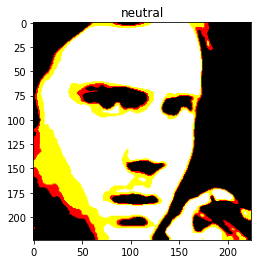

In [20]:
emotion_dict = {
    0: 'neutral',
    1: 'happiness',
    2: 'surprise',
    3: 'sadness',
    4: 'anger',
    5: 'disgust',
    6: 'fear',
    7: 'contempt'
}

import matplotlib.pyplot as plt
plt.imshow(feature[0,:,:,:])
plt.title(emotion_dict[np.argmax(lable[0])]);

# Model

In [21]:
vggface = VGGFace(model='resnet50', include_top=False, input_shape = (224,224,3))
vggface.trainable = False
vggface.summary()

94699520/94694792 [==============================] - 1s 0us/step
Model: "vggface_resnet50"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1/7x7_s2 (Conv2D)           (None, 112, 112, 64) 9408        input_1[0][0]                    
__________________________________________________________________________________________________
conv1/7x7_s2/bn (BatchNormaliza (None, 112, 112, 64) 256         conv1/7x7_s2[0][0]               
__________________________________________________________________________________________________
activation (Activation)         (None, 112, 112, 64) 0           conv1/7x7_s2/bn[0][0]            
__________________

In [22]:
from keras.models import Sequential
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization

# model = Sequential([vggface,
#                     Flatten(),
#                     Dropout(0.5),
#                     BatchNormalization(),
#                     Dense(128, activation='relu'),
#                     Dropout(0.5),
#                     BatchNormalization(),
#                     Dense(len(emotion_dict), activation='softmax', name = 'classifer')])
model = Sequential([vggface,
                    Flatten(),
                    Dropout(0.25),
                    Dense(2048, activation='relu'),
                    Dropout(0.25),
                    Dense(1024, activation='relu'),
                    Dense(8, name = 'classifer')])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vggface_resnet50 (Functional (None, 1, 1, 2048)        23561152  
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0         
_________________________________________________________________
dropout (Dropout)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 2048)              4196352   
_________________________________________________________________
dropout_1 (Dropout)          (None, 2048)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 1024)              2098176   
_________________________________________________________________
classifer (Dense)            (None, 8)                 8

In [23]:
# train_sequence = data_sequence(x_train,y_train,batch_size=64,target_dim=(224,224),n_classes=8,shuffle=True,smooth=0.0)
# val_sequence   = data_sequence(x_val,  y_val,  batch_size=64,target_dim=(224,224),n_classes=8,shuffle=True,smooth=0.0)
# test_sequence  = data_sequence(x_test, y_test, batch_size=64,target_dim=(224,224),n_classes=8,shuffle=True,smooth=0.0)

train_sequence = data_sequence(x_train, y_train, batch_size=64, target_dim=(224,224), n_classes=8, shuffle=True, augment=True)
val_sequence   = data_sequence(x_val,   y_val,   batch_size=64, target_dim=(224,224), n_classes=8, shuffle=False, augment=False)
test_sequence  = data_sequence(x_test,  y_test,  batch_size=64, target_dim=(224,224), n_classes=8, shuffle=False, augment=False)

### train only top layers

In [24]:
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

loss_function = CategoricalCrossentropy(from_logits=True)

checkpoint_fase1 = ModelCheckpoint(
    'model_v2_fase1_head_only.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

model.compile(optimizer = keras.optimizers.Adam(), loss=loss_function, metrics=['accuracy'])
hist = model.fit_generator(generator = train_sequence,
                           validation_data = val_sequence,
                           epochs = 20, 
                           class_weight=class_weight_dict,
                           callbacks=[checkpoint_fase1])

Epoch 1/20
443/443 [==============================] - ETA: 0s - loss: 2.0344 - accuracy: 0.4526
Epoch 00001: val_accuracy improved from -inf to 0.45455, saving model to model_v2_fase1_head_only.h5
443/443 [==============================] - 87s 195ms/step - loss: 2.0344 - accuracy: 0.4526 - val_loss: 1.4032 - val_accuracy: 0.4545
Epoch 2/20
443/443 [==============================] - ETA: 0s - loss: 1.3489 - accuracy: 0.5439
Epoch 00002: val_accuracy improved from 0.45455 to 0.56250, saving model to model_v2_fase1_head_only.h5
443/443 [==============================] - 82s 184ms/step - loss: 1.3489 - accuracy: 0.5439 - val_loss: 1.2129 - val_accuracy: 0.5625
Epoch 3/20
443/443 [==============================] - ETA: 0s - loss: 1.1935 - accuracy: 0.5728
Epoch 00003: val_accuracy improved from 0.56250 to 0.57017, saving model to model_v2_fase1_head_only.h5
443/443 [==============================] - 85s 192ms/step - loss: 1.1935 - accuracy: 0.5728 - val_loss: 1.1104 - val_accuracy: 0.5702
E

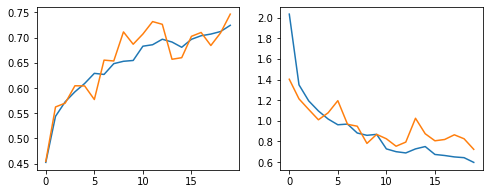

In [25]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.subplot(1,2,2)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

### finetune all layer, lr=1e-4

In [26]:
model = keras.models.load_model('model_v2_fase1_head_only.h5')

In [27]:
for layer in model.layers[0].layers:
    if 'bn' not in layer.name:
        layer.trainable = True

In [28]:
checkpoint_fase2 = ModelCheckpoint(
    'model_v2_fase2_finetune_medium_lr.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

model.compile(optimizer = keras.optimizers.Adam(1e-4), loss=loss_function, metrics=['accuracy'])
hist2 = model.fit_generator(
        generator=train_sequence,
        validation_data=val_sequence,
        epochs=10,
        class_weight=class_weight_dict,
        callbacks=[checkpoint_fase2] 
)

Epoch 1/10
443/443 [==============================] - ETA: 0s - loss: 2.1969 - accuracy: 0.1566
Epoch 00001: val_accuracy improved from -inf to 0.37557, saving model to model_v2_fase2_finetune_medium_lr.h5
443/443 [==============================] - 116s 261ms/step - loss: 2.1969 - accuracy: 0.1566 - val_loss: 2.0570 - val_accuracy: 0.3756
Epoch 2/10
443/443 [==============================] - ETA: 0s - loss: 2.0940 - accuracy: 0.2298
Epoch 00002: val_accuracy did not improve from 0.37557
443/443 [==============================] - 112s 254ms/step - loss: 2.0940 - accuracy: 0.2298 - val_loss: 2.0616 - val_accuracy: 0.1278
Epoch 3/10
443/443 [==============================] - ETA: 0s - loss: 2.0872 - accuracy: 0.2481
Epoch 00003: val_accuracy did not improve from 0.37557
443/443 [==============================] - 112s 253ms/step - loss: 2.0872 - accuracy: 0.2481 - val_loss: 2.0734 - val_accuracy: 0.0207
Epoch 4/10
443/443 [==============================] - ETA: 0s - loss: 2.0852 - accuracy

In [29]:
for key in ['accuracy','val_accuracy','loss','val_loss']:
    hist.history[key] = hist.history[key] + hist2.history[key]

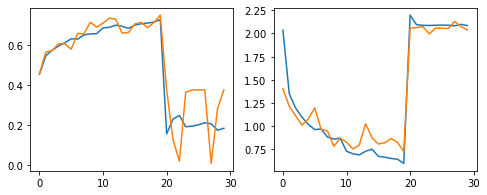

In [30]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.subplot(1,2,2)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

### finetune further all, lr=1e-5

In [31]:
from keras.callbacks import ModelCheckpoint

model = keras.models.load_model('model_v2_fase2_finetune_medium_lr.h5')

# check_point = ModelCheckpoint('VGGfaceTransfer_dropout_smoothing_keras_model', 
#                               monitor='val_acc', verbose=0, save_best_only=True,
#                               save_weights_only=False, mode='auto', period=1)

checkpoint_fase3 = ModelCheckpoint(
    'model_v2_final.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


model.compile(optimizer = keras.optimizers.Adam(1e-5), loss=loss_function, metrics=['accuracy'])
hist3 = model.fit_generator(
        generator=train_sequence,
        validation_data=val_sequence,
        epochs=10,
        class_weight=class_weight_dict,
        callbacks=[checkpoint_fase3]
)

Epoch 1/10
443/443 [==============================] - ETA: 0s - loss: 2.0160 - accuracy: 0.2520
Epoch 00001: val_accuracy improved from -inf to 0.28835, saving model to model_v2_final.h5
443/443 [==============================] - 115s 259ms/step - loss: 2.0160 - accuracy: 0.2520 - val_loss: 1.9440 - val_accuracy: 0.2884
Epoch 2/10
443/443 [==============================] - ETA: 0s - loss: 1.8904 - accuracy: 0.2478
Epoch 00002: val_accuracy improved from 0.28835 to 0.33750, saving model to model_v2_final.h5
443/443 [==============================] - 114s 258ms/step - loss: 1.8904 - accuracy: 0.2478 - val_loss: 1.7571 - val_accuracy: 0.3375
Epoch 3/10
443/443 [==============================] - ETA: 0s - loss: 1.6018 - accuracy: 0.4255
Epoch 00003: val_accuracy improved from 0.33750 to 0.50937, saving model to model_v2_final.h5
443/443 [==============================] - 114s 258ms/step - loss: 1.6018 - accuracy: 0.4255 - val_loss: 1.3111 - val_accuracy: 0.5094
Epoch 4/10
443/443 [========

In [32]:
ls

model_v2_fase1_head_only.h5           model_v2_final.h5
model_v2_fase2_finetune_medium_lr.h5


In [33]:
for key in ['accuracy','val_accuracy','loss','val_loss']:
    hist.history[key] = hist.history[key] + hist3.history[key]

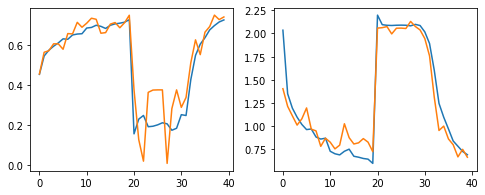

In [34]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.subplot(1,2,2)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

# model test

In [35]:
model = keras.models.load_model('model_v2_final.h5')

In [36]:
model.evaluate(test_sequence)

55/55 [==============================] - 8s 144ms/step - loss: 0.6780 - accuracy: 0.7420


[0.6779607534408569, 0.7420454621315002]

In [37]:
model.save('VGGfaceTransfer_dropout_smoothing_keras_model')

In [38]:
!tar -czvf VGGfaceTransfer_dropout_smoothing_keras_model.tar.gz VGGfaceTransfer_dropout_smoothing_keras_model

VGGfaceTransfer_dropout_smoothing_keras_model/
VGGfaceTransfer_dropout_smoothing_keras_model/variables/
VGGfaceTransfer_dropout_smoothing_keras_model/variables/variables.data-00000-of-00001
VGGfaceTransfer_dropout_smoothing_keras_model/variables/variables.index
VGGfaceTransfer_dropout_smoothing_keras_model/assets/
VGGfaceTransfer_dropout_smoothing_keras_model/saved_model.pb


In [39]:
from IPython.display import FileLink
FileLink(r'VGGfaceTransfer_dropout_smoothing_keras_model.tar.gz')

/kaggle/working/VGGfaceTransfer_dropout_smoothing_keras_model.tar.gz

### Confusion matrix

In [40]:
y_pred = []
y_true = []
for x,y in test_sequence:
    y_pred = y_pred + list(model.predict_classes(x))
    y_true = y_true + list(np.argmax(y,axis=1))

In [41]:
emotion_dict.values()

dict_values(['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt'])

In [42]:
emotion_dict

{0: 'neutral',
 1: 'happiness',
 2: 'surprise',
 3: 'sadness',
 4: 'anger',
 5: 'disgust',
 6: 'fear',
 7: 'contempt'}

In [43]:
confusion_matrix = tf.math.confusion_matrix(labels=y_true, predictions=y_pred).numpy()
confusion_matrix = np.around(confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis], decimals=2)

confusion_matrix = pd.DataFrame(confusion_matrix,
                                index = emotion_dict.values(), 
                                columns = emotion_dict.values())

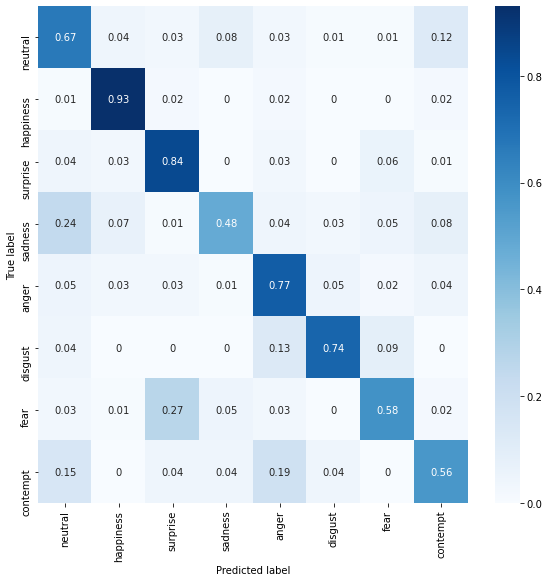

In [44]:
import seaborn as sns
figure = plt.figure(figsize=(8, 8))
sns.heatmap(confusion_matrix, annot=True,cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()